# Explainability / interpretability

In [6]:
import os
import torch
import numpy as np
import pandas as pd
import torch.nn as nn
import matplotlib.pyplot as plt

from torchvision import transforms
from captum.attr import visualization as viz
from captum.attr import LayerGradCam, GuidedGradCam
from sklearn.metrics import f1_score, accuracy_score

In [4]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="captum")

## Test dataset

In [5]:
root = '/gpfs01/berens/data/data/medical_imaging/Dermoscopy/ISIC_2018/Task3'
img_test_dir = os.path.join(root, 'Test_Input')

df_test = pd.read_csv(os.path.join(root, 'Test_GroundTruth_v2.csv'))
df_test.head()

,image,MEL,NV,BCC,AKIEC,BKL,DF,VASC,label
0,ISIC_0034524,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1
1,ISIC_0034525,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1
2,ISIC_0034526,0.0,0.0,0.0,0.0,1.0,0.0,0.0,4
3,ISIC_0034527,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1
4,ISIC_0034528,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1


## Load model and update the weights

In [8]:
xai = False
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu') 
model = Explainable_model(network='resnet50', num_classes=7) if xai else build_model(num_classes=7, backbone='resnet50')

if xai:
    pass
else:
    model.load_state_dict(torch.load('save/best_model.pth', map_location=device))

## Posthoc XAI: GradCAM and GuidedGradCAM 
- [Captum](https://github.com/meta-pytorch/captum)
- [TorchCAM](https://github.com/frgfm/torch-cam)

In [23]:
def compute_attributions(model, image_tensor, device, target_class=None):
    """
    image_tensor: [1, C, H, W], already normalized, on the correct device
    """
    model.to(device)
    model.eval()

    # target the last conv block, same choice as before
    target_layer = model.layer4[-1]
    
    gradcam = LayerGradCam(model, target_layer)
    guided_gradcam = GuidedGradCam(model, target_layer)
    
    input_tensor = image_tensor.clone().to(device).requires_grad_()

    if target_class is None:
        with torch.no_grad():
            output = model(input_tensor)
            target_class = output.argmax(dim=1).item()

    # Grad-CAM: coarse, low-res localization map (size of target_layer's feature map)
    gradcam_attr = gradcam.attribute(input_tensor, target=target_class)

    # upsample Grad-CAM to input resolution for visualization
    gradcam_attr_upsampled = LayerGradCam.interpolate(
        gradcam_attr, image_tensor.shape[2:]
    )

    # Guided Grad-CAM: pixel-level, high-res attribution
    guided_attr = guided_gradcam.attribute(input_tensor, target=target_class)

    return gradcam_attr_upsampled.squeeze(), guided_attr.squeeze(), target_class

In [37]:
def get_ts_img(root, fname, img_path, batch=True, IMG_SIZE = (450, 600)):
    img_path = os.path.join(root,  img_path, fname + '.jpg')
    image = Image.open(img_path).convert('RGB')

    val_transform = transforms.Compose([
        transforms.Resize(IMG_SIZE),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])

    transform_img_ = val_transform(image)
    transform_img = transform_img_.unsqueeze(0) if batch else transform_img_
    
    np_img = np.array(image, dtype=np.float32) / 255.0
    
    return transform_img, np_img

In [38]:
class_cols = ['MEL', 'NV', 'BCC', 'AKIEC', 'BKL', 'DF', 'VASC']
label_map = {i: c for i, c in enumerate(class_cols)}

In [62]:
df_tmp = df_test.sample()
fname, label = df_tmp.image.tolist()[0], df_tmp.label.tolist()[0]

ts_img, np_img = get_ts_img(root, fname, img_test_dir)
ts_img.shape

torch.Size([1, 3, 450, 600])

In [63]:
np_img.shape

(450, 600, 3)

In [64]:
gc, guided_gc, pred = compute_attributions(model, ts_img, device)

gradcam_np = gc.detach().cpu().numpy()
guided_np = guided_gc.detach().cpu().numpy().mean(axis=0)

gradcam_np.shape, guided_np.shape

((450, 600), (450, 600))

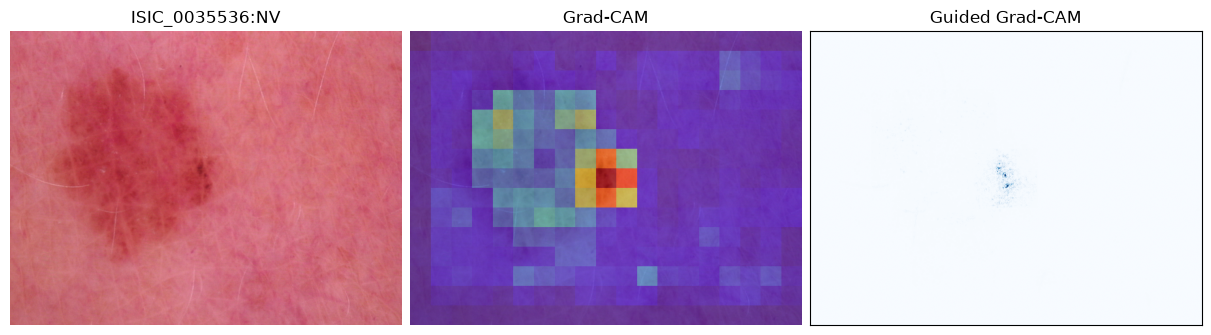

In [65]:
titles = [fname, "GradCAM", "Guided GradCAM"] 
imgs = [np_img, gc, guided_gc]

fig, axes = plt.subplots(1, 3, figsize=(12, 4), constrained_layout=True)

axes[0].imshow(np_img)
axes[0].set_title(f'{fname}:{label_map[label]}')
axes[0].axis("off")

axes[1].imshow(np_img)
axes[1].imshow(gradcam_np, cmap='jet', alpha=0.5)
axes[1].set_title('Grad-CAM')
axes[1].axis('off')

# Guided Grad-CAM uses Captum's built-in visualization (handles normalization/clipping)
viz.visualize_image_attr(
    guided_np, np_img, method='heat_map', sign='absolute_value',
    show_colorbar=False, title='Guided Grad-CAM', plt_fig_axis=(fig, axes[2]) )

#fig.savefig("figure.png", dpi=300, bbox_inches="tight")
plt.show()

## Multiple examples

In [ ]:
test_loader_shuffled = DataLoader(test_loader.dataset, batch_size=32, shuffle=True)
#images, labels = next(iter(test_loader))
images, labels = next(iter(test_loader_shuffled))

for i in range(3):
    orig = denormalize(images[i], mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    orig = orig.permute(1, 2, 0).clamp(0, 1).numpy()

    input_tensor = images[i:i+1].to(device)

    show_captum_attributions(input_tensor, orig, label_map, device, true_label=labels[i].item())

In [72]:
df_tmp.iloc[0].image

'ISIC_0035143'

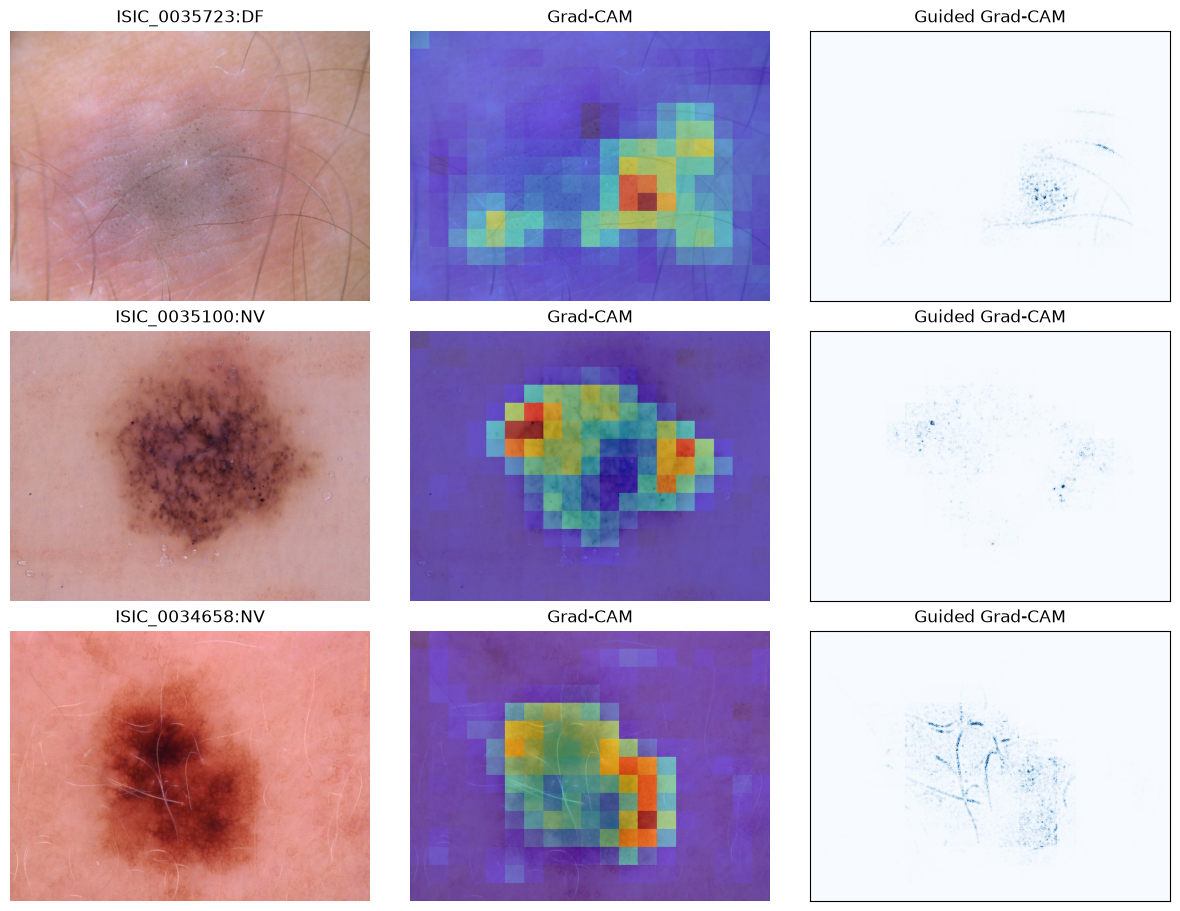

In [98]:
n=3
df_tmp = df_test.sample(3)
fig, axes = plt.subplots(n, 3, figsize=(12, 3*n), constrained_layout=True)

for i in range(n):    
    row = df_tmp.iloc[i]
    fname, label = row.image, row.label
    ts_img, np_img = get_ts_img(root, fname, img_test_dir)

    gc, guided_gc, pred = compute_attributions(model, ts_img, device)
    gradcam_np = gc.detach().cpu().numpy()
    guided_np = guided_gc.detach().cpu().numpy().mean(axis=0)

    axes[i,0].imshow(np_img)
    axes[i,0].set_title(f'{fname}:{label_map[label]}')
    axes[i,0].axis("off")
    
    axes[i,1].imshow(np_img)
    axes[i,1].imshow(gradcam_np, cmap='jet', alpha=0.5)
    axes[i,1].set_title('Grad-CAM')
    axes[i,1].axis('off')
    
    # Guided Grad-CAM uses Captum's built-in visualization (handles normalization/clipping)
    viz.visualize_image_attr(
        guided_np, np_img, method='heat_map', sign='absolute_value',
        show_colorbar=False, title='Guided Grad-CAM', plt_fig_axis=(fig, axes[i,2]), use_pyplot=False )